In [1]:
import os
from glob import glob
from dotenv import load_dotenv

from utils.livevideosocial_proc import plot_preprocessing_steps, preprocess_fus_data

import numpy as np
import pandas as pd
from nilearn.glm.first_level import make_first_level_design_matrix, FirstLevelModel
from scipy.stats import gamma
from scipy import signal, stats
import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from joblib import Parallel, delayed

In [2]:
load_dotenv()
base_dir = os.getenv('BASE_DIR')
task_dir = os.path.join(base_dir, 'task_data', 'video_live_social')
videosocial_2d = os.path.join(task_dir, '20241128_videosocial_2d')
livesocial_2d = os.path.join(task_dir, '20241130_livesocial_2d')

pixdim[1,2,3] should be positive; setting to abs of pixdim values


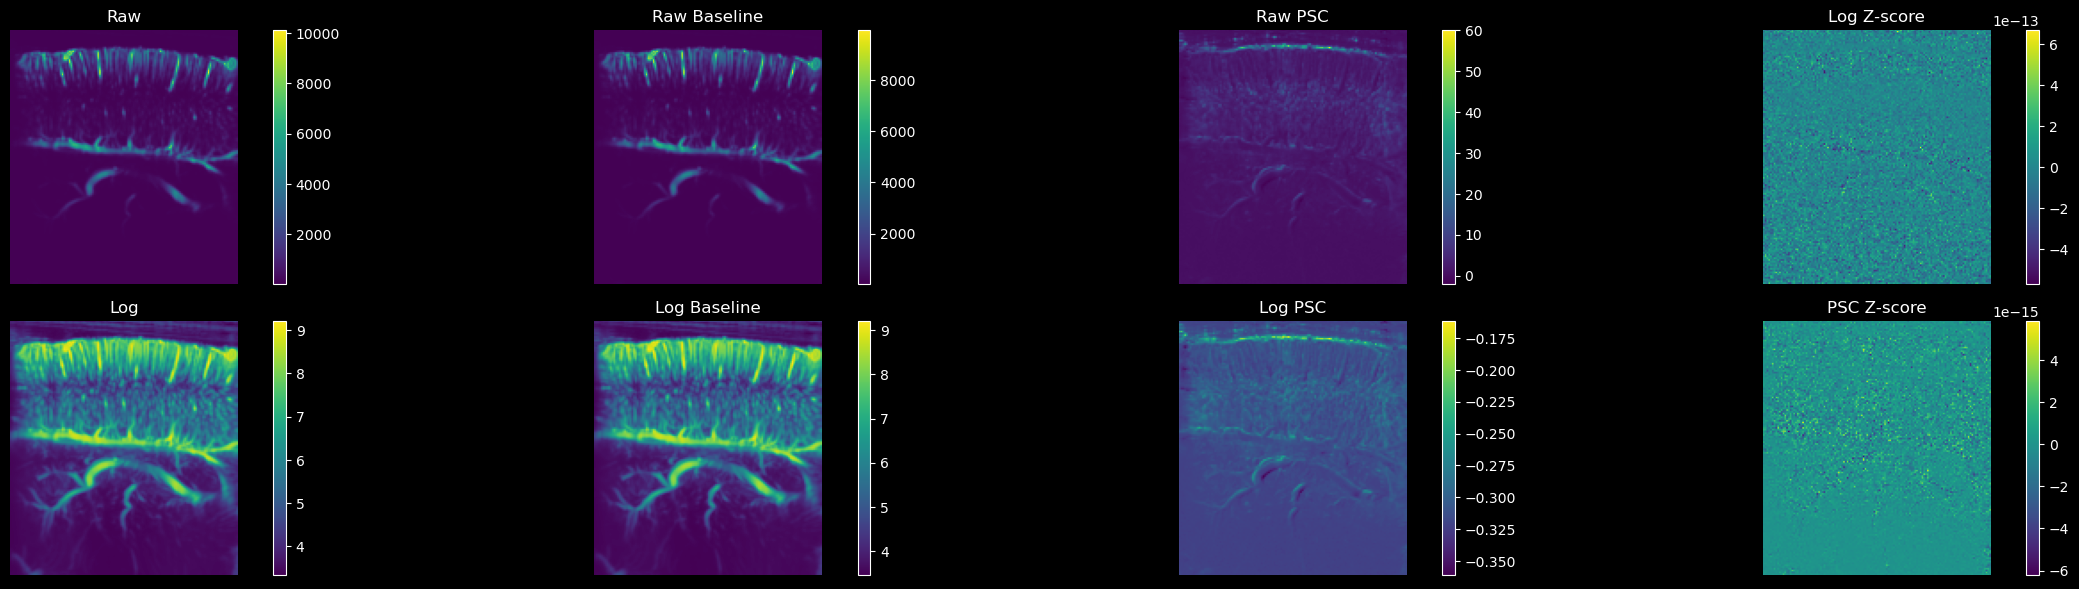

In [3]:
video_data  = plot_preprocessing_steps(videosocial_2d)

pixdim[1,2,3] should be positive; setting to abs of pixdim values


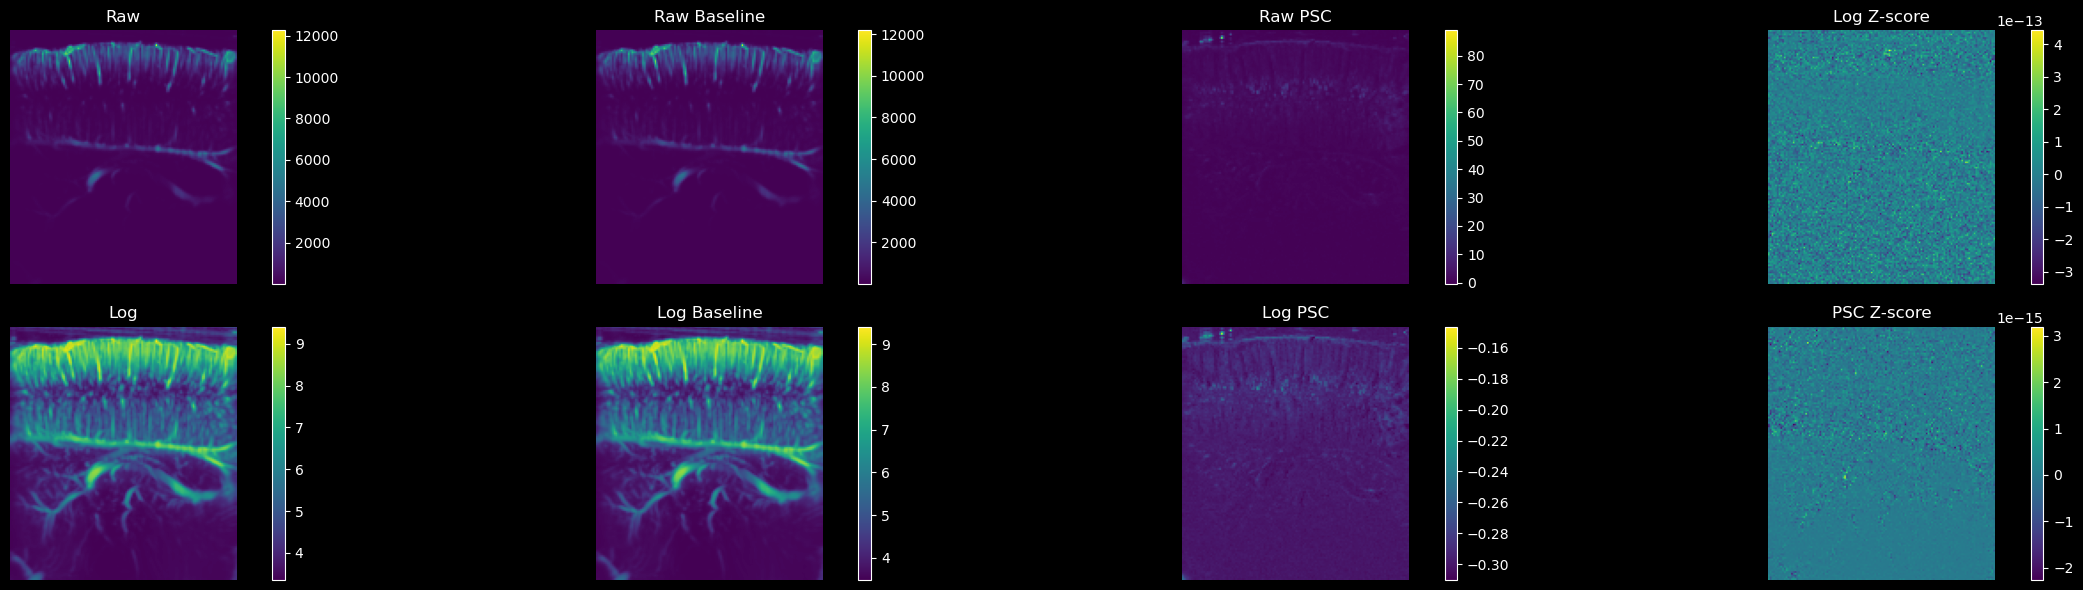

In [4]:
live_data  = plot_preprocessing_steps(livesocial_2d)


In [5]:
class FUSGLMAnalysis:
    def __init__(self, sampling_rate=4):
        self.sampling_rate = sampling_rate
        
    def create_hrf(self, duration=30):
        """Create HRF model using double gamma function"""
        t = np.linspace(0, duration, int(duration * self.sampling_rate))
        # Main response
        peak1 = gamma.pdf(t, 6, loc=0, scale=1)
        # Post-stimulus undershoot
        peak2 = gamma.pdf(t, 12, loc=0, scale=1)
        hrf = peak1 - 0.35 * peak2
        return hrf / np.max(hrf)
    
    def create_design_matrix(self, events, total_timepoints, glm_type='all_vs_live'):
        X = np.zeros((total_timepoints, 3 if glm_type == 'video_contrasts' else 2))
        hrf = self.create_hrf()
        
        if glm_type == 'video_contrasts':
            condition_map = {1: 'partner', 2: 'stranger', 3: 'object'}
            conditions = ['partner', 'stranger', 'object']
            for i, condition in enumerate(conditions):
                events_subset = [e for e in events if condition_map[e['condition']] == condition]
                X[:, i] = self._create_regressor(events_subset, total_timepoints, hrf)
        else:
            video_events = [e for e in events if e['type'] == 'video']
            if glm_type == 'partner_vs_live':
                video_events = [e for e in video_events if e['condition'] == 1]  # 1 for partner
            
            live_events = [e for e in events if e['type'] == 'live']
            X[:, 0] = self._create_regressor(video_events, total_timepoints, hrf)
            X[:, 1] = self._create_regressor(live_events, total_timepoints, hrf)
            
        print(f"Total events: {len(events)}")
        print(f"Video events: {len([e for e in events if e['type'] == 'video'])}")
        print(f"Live events: {len([e for e in events if e['type'] == 'live'])}")
        
        return np.column_stack([X, np.ones(total_timepoints)])
    
    def check_design_matrix(self, design_matrix):
        """Check design matrix for issues"""
        # Print correlation matrix
        print("Design matrix stats:")
        print(f"Shape: {design_matrix.shape}")
        print(f"Min: {np.min(design_matrix)}")
        print(f"Max: {np.max(design_matrix)}")
        print(f"Number of zeros: {np.sum(design_matrix == 0)}")
        print("\nColumn sums:")
        print(np.sum(design_matrix, axis=0))
        print("\nFirst few rows:")
        print(design_matrix[:10])
        
        corr = np.corrcoef(design_matrix.T)
        print("Correlation matrix:")
        print(corr)
        
        # Check for rank
        rank = np.linalg.matrix_rank(design_matrix)
        print(f"\nMatrix rank: {rank} out of {design_matrix.shape[1]} columns")
        
        # Check condition number
        cond = np.linalg.cond(design_matrix)
        print(f"Condition number: {cond}")
        
    def _create_regressor(self, events, total_timepoints, hrf):
        reg = np.zeros(total_timepoints)
        
        for evt in events:
            # Convert from seconds to timepoints
            onset_idx = int(evt['onset'] / self.sampling_rate)  # Changed division
            duration_idx = int(evt['duration'] * self.sampling_rate)
            
            if onset_idx + duration_idx < total_timepoints:
                reg[onset_idx:onset_idx + duration_idx] = 1
                
        reg_conv = np.convolve(reg, hrf, mode='same')
        return reg_conv

    def fit_glm(self, data, design_matrix):
        """
        Fit GLM using OLS with temporal autocorrelation correction
        """
        # Reshape data if needed
        if len(data.shape) == 3:
            orig_shape = data.shape
            data = data.reshape(-1, data.shape[-1])
            
        n_voxels = data.shape[0]
        betas = np.zeros((n_voxels, design_matrix.shape[1]))
        residuals = np.zeros((n_voxels, data.shape[1]))
        
        for i in range(n_voxels):
            # Fit AR model to estimate temporal autocorrelation
            model = sm.OLS(data[i], design_matrix)
            results = model.fit()
            betas[i] = results.params
            residuals[i] = results.resid
            
            # Estimate AR parameters from residuals
            ar_params = sm.regression.yule_walker(results.resid, order=1)[0]
            
            # Apply AR correction
            whitened_data = data[i][1:] - ar_params * data[i][:-1]
            whitened_X = design_matrix[1:] - ar_params * design_matrix[:-1]
            
            # Refit with whitened data
            model_whitened = sm.OLS(whitened_data, whitened_X)
            results_whitened = model_whitened.fit()
            betas[i] = results_whitened.params
            
        if len(data.shape) == 3:
            betas = betas.reshape(orig_shape[:-1] + (-1,))
            
        return betas, residuals
    
    def run_analysis(self, data, events, glm_type='all_vs_live'):
        design_matrix = self.create_design_matrix(events, data.shape[-1], glm_type)
        betas, residuals = self.fit_glm(data, design_matrix)
        
        if glm_type == 'video_contrasts':
            contrasts = {
                'partner_vs_stranger': np.array([1, -1, 0, 0]),
                'partner_vs_object': np.array([1, 0, -1, 0]),
                'stranger_vs_object': np.array([0, 1, -1, 0])
            }
        else:
            contrasts = {'video_vs_live': np.array([1, -1, 0])}
            
        contrast_maps = {}
        for name, contrast_vector in contrasts.items():
            contrast_maps[name] = self.run_contrast_analysis(betas, contrast_vector, 
                                                           residuals, design_matrix)
        return contrast_maps
    
    def run_contrast_analysis(self, betas, contrast_vector, residuals, design_matrix):
        """
        Compute contrast maps and statistical significance
        """
        # Calculate contrast map
        contrast_map = np.dot(betas, contrast_vector)
        
        # Calculate standard error
        mse = np.mean(residuals ** 2, axis=1)
        contrast_var = np.dot(contrast_vector.T, 
                            np.linalg.inv(np.dot(design_matrix.T, design_matrix)).dot(contrast_vector))
        se = np.sqrt(mse * contrast_var)
        
        # Calculate t-statistics
        t_stats = contrast_map / se
        
        # Calculate p-values
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), design_matrix.shape[0] - design_matrix.shape[1]))
        
        # FDR correction
        _, p_corrected = fdrcorrection(p_values.flatten())
        p_corrected = p_corrected.reshape(p_values.shape)
        
        return contrast_map, t_stats, p_corrected
    
    def compute_effect_size(self, contrast_map, residuals):
        """
        Calculate Cohen's d effect size
        """
        pooled_std = np.sqrt(np.mean(residuals ** 2, axis=1))
        cohens_d = contrast_map / pooled_std[:, np.newaxis]
        return cohens_d

    def qc_metrics(self, data, design_matrix, residuals):
        """
        Compute quality control metrics
        """
        metrics = {
            'temporal_snr': np.mean(data, axis=1) / np.std(data, axis=1),
            'design_correlation': np.corrcoef(design_matrix.T),
            'residual_autocorr': [sm.stats.diagnostic.acorr_ljungbox(res, lags=20)[1] 
                                for res in residuals],
            'variance_explained': 1 - (np.var(residuals, axis=1) / np.var(data, axis=1))
        }
        return metrics

In [6]:
def plot_contrast_results(contrast_data, data_shape=(128, 143), figsize=(15, 5)):
    """
    Plot contrast results showing effect size, t-statistics, and significance.
    """
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    for name, (contrast, t_stats, p_vals) in contrast_data.items():
        # Reshape data back to original dimensions
        contrast_map = contrast.reshape(data_shape)
        t_map = t_stats.reshape(data_shape)
        p_map = p_vals.reshape(data_shape)
        
        # Create significance mask
        sig_mask = p_map < 0.05  # Significant regions
        
        # Plot contrast values
        im1 = axes[0].imshow(contrast_map.T, cmap='RdBu_r')
        axes[0].set_title(f'{name}\nContrast Values')
        plt.colorbar(im1, ax=axes[0])
        
        # Plot t-statistics
        im2 = axes[1].imshow(t_map.T, cmap='RdBu_r', 
                            vmin=-10, vmax=10)
        axes[1].set_title('T-Statistics')
        plt.colorbar(im2, ax=axes[1])
        
        # Plot significant regions with a different visualization
        # Create a masked array where non-significant values are transparent
        masked_t = np.ma.masked_array(t_map.T, mask=~sig_mask.T)
        
        # First plot a gray background for non-significant regions
        axes[2].imshow(np.zeros_like(t_map.T), cmap='gray', alpha=0.3)
        
        # Then plot significant regions
        im3 = axes[2].imshow(masked_t, cmap='RdBu_r',
                            vmin=-10, vmax=10)
        axes[2].set_title('Significant T-Stats\n(p < 0.05)')
        plt.colorbar(im3, ax=axes[2])
        
        # Turn off axis labels
        for ax in axes:
            ax.axis('off')
    
    plt.tight_layout()
    return fig

In [7]:
def combine_video_live_data(data_all):
    """
    Combine video and live data, adjusting event timings accordingly.
    
    Parameters:
        data_all: dict containing 'video_data', 'live_data', 'video_events', and 'live_events'
    
    Returns:
        dict containing:
            'data': combined video and live data
            'events': list of formatted and adjusted events
    """
    # Concatenate data
    combined_data = np.concatenate([data_all['video_data'], data_all['live_data']], axis=-1)
    
    # Process video events
    video_events_formatted = []
    for evt in data_all['video_events']:
        video_events_formatted.append({
            'onset': evt['codes'][1],  # code 9 is video onset
            'duration': evt['duration'],
            'condition': evt['condition'],
            'type': 'video'
        })
    
    # Process live events and adjust timing
    live_events_formatted = []
    live_time_offset = data_all['video_data'].shape[-1]
    for evt in data_all['live_events']:
        live_events_formatted.append({
            'onset': evt['codes'][2] + live_time_offset,  # code 2 is live onset, add offset
            'duration': evt['duration'],
            'condition': evt['condition'],
            'type': 'live'
        })
    
    # Combine events
    combined_events = video_events_formatted + live_events_formatted
    
    return {
        'data': combined_data,
        'events': combined_events
    }

In [8]:
def summarize_contrast_stats(contrast_data):
    """
    Print summary statistics for each contrast.
    
    Parameters:
        contrast_data: dict with contrast names as keys and (contrast, t-stat, p-value) as values
    """
    for name, (contrast, t_stats, p_vals) in contrast_data.items():
        print(f"\nContrast: {name}")
        print("-" * 50)
        print(f"Contrast values range: [{contrast.min():.3f}, {contrast.max():.3f}]")
        print(f"T-statistics range: [{t_stats.min():.3f}, {t_stats.max():.3f}]")
        print(f"Number of significant voxels (p < 0.05): {np.sum(p_vals < 0.05)}")
        print(f"Number of significant voxels (p < 0.01): {np.sum(p_vals < 0.01)}")
        print(f"Number of significant voxels (p < 0.001): {np.sum(p_vals < 0.001)}")

## Video (all conditions) vs Live Social (first 30 trials each)


In [9]:
data_all = preprocess_fus_data(
    video_dir=videosocial_2d,
    live_dir=livesocial_2d,
    glm_type='all_vs_live'
)

pixdim[1,2,3] should be positive; setting to abs of pixdim values
pixdim[1,2,3] should be positive; setting to abs of pixdim values


Before slicing:
Video data shape: (128, 143, 9000)
Live data shape: (128, 143, 3513)
First video event:
Slice start: 19.727225399999952
Raw onset: 19.727225399999952
Adjusted onset: 0.0

First live event:
Slice start: 55.83264690000033
Raw onset: 55.83264690000033
Adjusted onset: 0.0

Adjusting video events:
Slice start: 19.727225399999952
Number of input events: 203

Event 0:
Codes: {9: 19.650860199999443, 1: 19.727225399999952, 2: 20.06131120000009, 18: 25.121251499999744}
Using onset_code: 1
Adjusted onset: 0.0

Event 1:
Codes: {9: 38.122198499999286, 1: 38.19671070000004, 2: 38.53062779999982, 18: 43.59033629999976}
Using onset_code: 1
Adjusted onset: 18.469485300000088

Event 2:
Codes: {9: 55.59124199999951, 1: 55.64711719999923, 2: 56.01450449999993, 18: 61.05786779999926}
Using onset_code: 1
Adjusted onset: 35.91989179999928

Event 3:
Codes: {9: 72.06031230000008, 1: 72.14589049999995, 2: 72.47990069999923, 18: 77.53990059999978}
Using onset_code: 1
Adjusted onset: 52.4186651

E

In [10]:
combined_all = combine_video_live_data(data_all)
combined_data_all = combined_all['data']
events_all = combined_all['events']

In [11]:
analyzer_all = FUSGLMAnalysis(sampling_rate=4)
design_matrix_all = analyzer_all.create_design_matrix(events_all, combined_data_all.shape[-1], glm_type='all_vs_live')
analyzer_all.check_design_matrix(design_matrix_all)

Total events: 60
Video events: 30
Live events: 30
Design matrix stats:
Shape: (4634, 3)
Min: -4.068723436121916
Max: 19.020156142241223
Number of zeros: 8755

Column sums:
[1591.13240226 2721.16075251 4634.        ]

First few rows:
[[16.92192152  0.          1.        ]
 [16.77507161  0.          1.        ]
 [16.63450851  0.          1.        ]
 [16.50064986  0.          1.        ]
 [16.37377909  0.          1.        ]
 [16.25406173  0.          1.        ]
 [16.14156098  0.          1.        ]
 [16.03625229  0.          1.        ]
 [15.9380371   0.          1.        ]
 [15.84675536  0.          1.        ]]
Correlation matrix:
[[ 1.         -0.02904639         nan]
 [-0.02904639  1.                 nan]
 [        nan         nan         nan]]

Matrix rank: 3 out of 3 columns
Condition number: 3.168885568455308


/Users/yibeichen/micromamba/envs/neuro/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/yibeichen/micromamba/envs/neuro/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [12]:

# Run analysis
analyzer_all = FUSGLMAnalysis(sampling_rate=4)
contrast_maps_all = analyzer_all.run_analysis(
    data=combined_data_all,
    events=events_all,
    glm_type='all_vs_live'  # or 'partner_vs_live'
)

Total events: 60
Video events: 30
Live events: 30


In [13]:
contrast_maps_all

{'video_vs_live': (array([-0.10441635, -0.11396061, -0.3363769 , ...,  0.01194064,
         -0.02043553, -0.00807056]),
  array([-5.48655843, -5.64330401, -9.62874869, ...,  0.73302997,
         -1.28544257, -0.52373143]),
  array([4.17398712e-07, 1.88872819e-07, 0.00000000e+00, ...,
         5.77664787e-01, 2.95478146e-01, 6.98264182e-01]))}

/var/folders/xh/0b2t8trn63n0nz_9qb97s_940000gn/T/ipykernel_56898/2193921800.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_all.show()


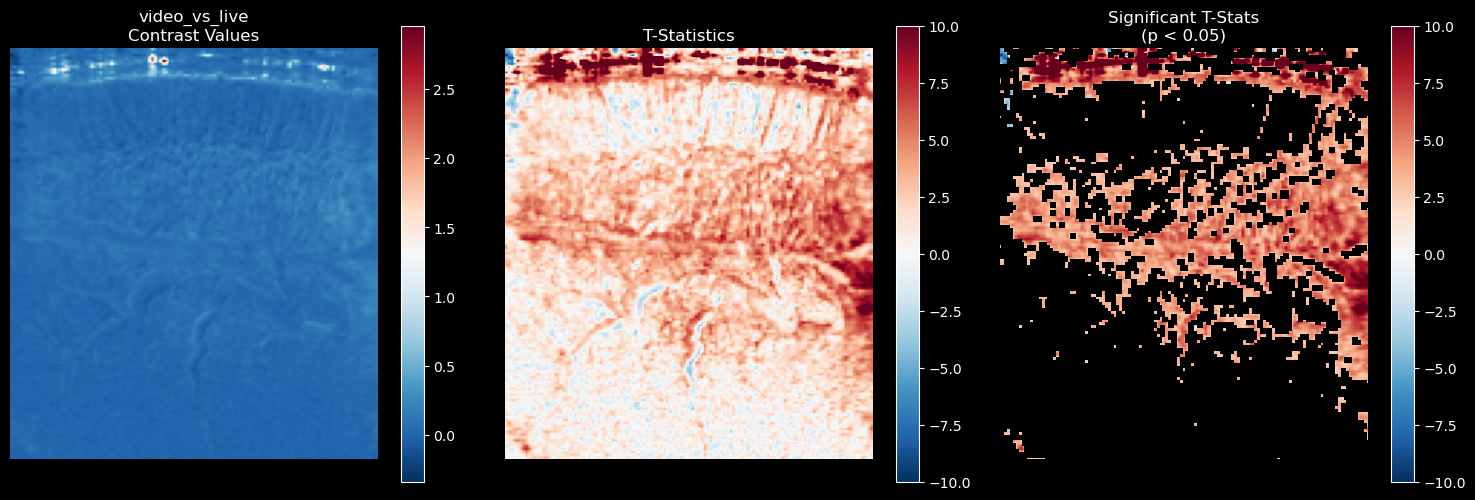

In [14]:
# Usage:
fig_all = plot_contrast_results(contrast_maps_all)
fig_all.show()

In [15]:
summarize_contrast_stats(contrast_maps_all)


Contrast: video_vs_live
--------------------------------------------------
Contrast values range: [-0.336, 2.956]
T-statistics range: [-9.629, 64.672]
Number of significant voxels (p < 0.05): 8841
Number of significant voxels (p < 0.01): 7005
Number of significant voxels (p < 0.001): 5035


## 2. Video (partner only) vs Live Social (matched trials)

In [16]:
data_partner = preprocess_fus_data(
    video_dir=videosocial_2d,
    live_dir=livesocial_2d,
    glm_type='partner_vs_live'
)

pixdim[1,2,3] should be positive; setting to abs of pixdim values
pixdim[1,2,3] should be positive; setting to abs of pixdim values


Before slicing:
Video data shape: (128, 143, 9000)
Live data shape: (128, 143, 3513)
First video event:
Slice start: 72.14589049999995
Raw onset: 72.14589049999995
Adjusted onset: 0.0

First live event:
Slice start: 934.6598184999998
Raw onset: 934.6598184999998
Adjusted onset: 0.0

Adjusting video events:
Slice start: 72.14589049999995
Number of input events: 67

Event 0:
Codes: {9: 72.06031230000008, 1: 72.14589049999995, 2: 72.47990069999923, 18: 77.53990059999978}
Using onset_code: 1
Adjusted onset: 0.0

Event 1:
Codes: {9: 128.4304930999997, 1: 128.47236189999967, 2: 128.8228756999997, 18: 133.8829300999996}
Using onset_code: 1
Adjusted onset: 56.32647139999972

Event 2:
Codes: {9: 183.79202029999942, 1: 183.8299247999994, 2: 184.18065099999967, 18: 189.24048409999978}
Using onset_code: 1
Adjusted onset: 111.68403429999944

Event 3:
Codes: {9: 218.7040939999997, 1: 218.74791860000005, 2: 219.08196299999963, 18: 224.14177859999927}
Using onset_code: 1
Adjusted onset: 146.6020281000

In [17]:
combined_partner = combine_video_live_data(data_partner)
combined_data_partner = combined_partner['data']
events_partner = combined_partner['events']

In [18]:
# Run analysis
analyzer_partner = FUSGLMAnalysis(sampling_rate=4)
design_matrix_partner = analyzer_partner.create_design_matrix(events_partner, combined_data_partner.shape[-1], glm_type='partner_vs_live')
analyzer_partner.check_design_matrix(design_matrix_partner)
contrast_maps_partner = analyzer_partner.run_analysis(
    data=combined_data_partner,
    events=events_partner,
    glm_type='partner_vs_live' 
)

Total events: 60
Video events: 30
Live events: 30
Design matrix stats:
Shape: (5989, 3)
Min: -4.068723436121916
Max: 19.020156142241223
Number of zeros: 11082

Column sums:
[5671.95439069 4171.44972501 5989.        ]

First few rows:
[[18.94544047  0.          1.        ]
 [18.867192    0.          1.        ]
 [18.76692336  0.          1.        ]
 [18.64830025  0.          1.        ]
 [18.51474624  0.          1.        ]
 [18.36942615  0.          1.        ]
 [18.21523608  0.          1.        ]
 [18.05479916  0.          1.        ]
 [17.89046632  0.          1.        ]
 [17.72432127  0.          1.        ]]
Correlation matrix:
[[ 1.         -0.05587277         nan]
 [-0.05587277  1.                 nan]
 [        nan         nan         nan]]

Matrix rank: 3 out of 3 columns
Condition number: 4.057110208222364
Total events: 60
Video events: 30
Live events: 30


In [19]:
contrast_maps_partner

{'video_vs_live': (array([-0.10832949,  0.07287748, -0.12957762, ...,  0.06211908,
          0.03799656,  0.0246851 ]),
  array([-8.41281207,  5.68939226, -5.82583683, ...,  5.97677177,
          3.70757898,  2.43466078]),
  array([0.00000000e+00, 3.34994529e-08, 1.54341893e-08, ...,
         6.41072977e-09, 3.77195332e-04, 2.23703943e-02]))}

/var/folders/xh/0b2t8trn63n0nz_9qb97s_940000gn/T/ipykernel_56898/1476836880.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_partner.show()


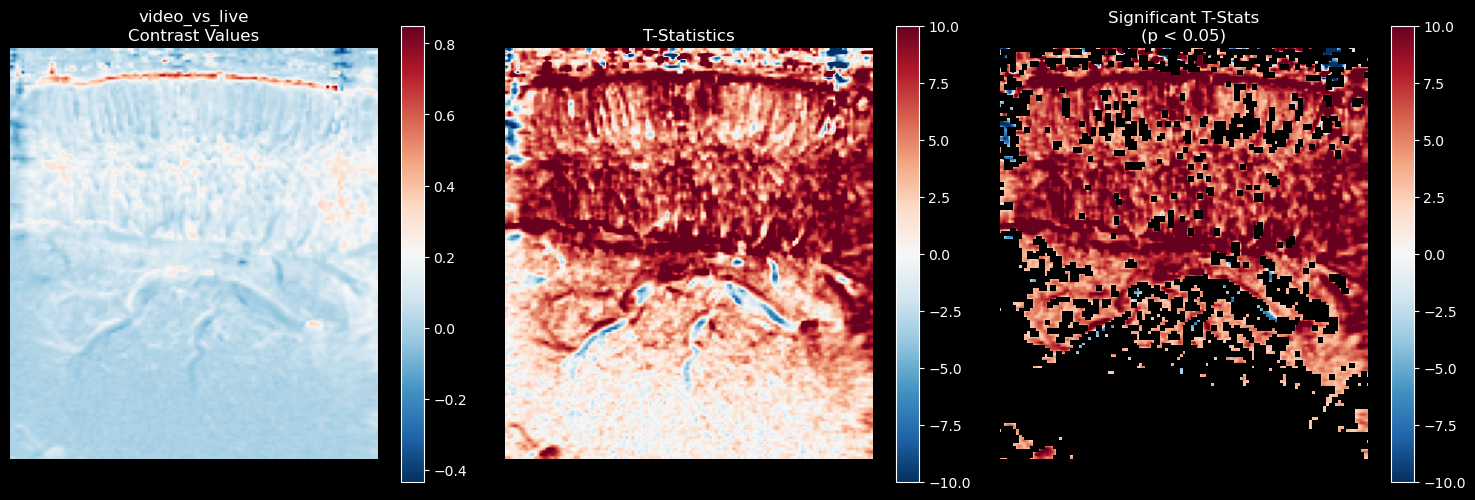

In [20]:
fig_partner = plot_contrast_results(contrast_maps_partner)
fig_partner.show()

In [21]:
summarize_contrast_stats(contrast_maps_partner)


Contrast: video_vs_live
--------------------------------------------------
Contrast values range: [-0.434, 0.851]
T-statistics range: [-33.044, 49.772]
Number of significant voxels (p < 0.05): 12798
Number of significant voxels (p < 0.01): 11729
Number of significant voxels (p < 0.001): 10664


## 3. Video contrasts (partner vs stranger vs object)


In [22]:
data_video = preprocess_fus_data(
    video_dir=videosocial_2d,
    glm_type='video_contrasts' 
)

pixdim[1,2,3] should be positive; setting to abs of pixdim values



Adjusting video events:
Slice start: 19.727225399999952
Number of input events: 203

Event 0:
Codes: {9: 19.650860199999443, 1: 19.727225399999952, 2: 20.06131120000009, 18: 25.121251499999744}
Using onset_code: 1
Adjusted onset: 0.0

Event 1:
Codes: {9: 38.122198499999286, 1: 38.19671070000004, 2: 38.53062779999982, 18: 43.59033629999976}
Using onset_code: 1
Adjusted onset: 18.469485300000088

Event 2:
Codes: {9: 55.59124199999951, 1: 55.64711719999923, 2: 56.01450449999993, 18: 61.05786779999926}
Using onset_code: 1
Adjusted onset: 35.91989179999928

Event 3:
Codes: {9: 72.06031230000008, 1: 72.14589049999995, 2: 72.47990069999923, 18: 77.53990059999978}
Using onset_code: 1
Adjusted onset: 52.4186651

Event 4:
Codes: {9: 90.54057569999988, 1: 90.58186709999974, 2: 90.91579319999984, 18: 95.97567829999936}
Using onset_code: 1
Adjusted onset: 70.85464169999979

Event 5:
Codes: {9: 109.97596290000001, 1: 110.01964119999957, 2: 110.37029189999976, 18: 115.43020509999951}
Using onset_cod

In [23]:
brain_data = data_video['video_data']
events = data_video['video_events']

In [24]:
# Run analysis
analyzer_video = FUSGLMAnalysis(sampling_rate=4)
design_matrix_video = analyzer_video.create_design_matrix(events, brain_data.shape[-1], glm_type='video_contrasts')
analyzer_video.check_design_matrix(design_matrix_video)
contrast_maps_video = analyzer_video.run_analysis(
    data=brain_data,
    events=events,
    glm_type='video_contrasts'
)


Total events: 30
Video events: 30
Live events: 0
Design matrix stats:
Shape: (9000, 4)
Min: -4.068723436121916
Max: 18.867191997155917
Number of zeros: 26388

Column sums:
[1516.37523873 1419.64022182 1406.80206168 9000.        ]

First few rows:
[[16.92192152 16.37377909 18.867192    1.        ]
 [16.77507161 16.25406173 18.76692336  1.        ]
 [16.63450851 16.14156098 18.64830025  1.        ]
 [16.50064986 16.03625229 18.51474624  1.        ]
 [16.37377909 15.9380371  18.36942615  1.        ]
 [16.25406173 15.84675536 18.21523608  1.        ]
 [16.14156098 15.76219705 18.05479916  1.        ]
 [16.03625229 15.68411257 17.89046632  1.        ]
 [15.9380371  15.61222203 17.72432127  1.        ]
 [15.84675536 15.54622348 17.55818897  1.        ]]
Correlation matrix:
[[1.         0.99499648 0.97919467        nan]
 [0.99499648 1.         0.99135827        nan]
 [0.97919467 0.99135827 1.                nan]
 [       nan        nan        nan        nan]]

Matrix rank: 4 out of 4 columns


In [25]:
contrast_maps_video

{'partner_vs_stranger': (array([-0.17102052,  0.75276712, -0.47236658, ...,  2.40622998,
          1.57640569,  1.1279323 ]),
  array([-0.35053099,  1.57899263, -0.54506236, ...,  5.60357015,
          3.8285967 ,  2.83898145]),
  array([7.59517596e-01, 1.45978779e-01, 6.30689731e-01, ...,
         2.22167891e-07, 3.43908202e-04, 7.81416650e-03])),
 'partner_vs_object': (array([-0.3673909 , -0.02727398, -0.06382861, ...,  0.59814035,
          0.29797022,  0.14055133]),
  array([-2.22199263, -0.1688123 , -0.2173294 , ...,  4.11023651,
          2.13540627,  1.04387984]),
  array([3.75713750e-02, 8.86631632e-01, 8.53605788e-01, ...,
         1.07164538e-04, 4.60019407e-02, 3.43939658e-01])),
 'stranger_vs_object': (array([-0.19637038, -0.7800411 ,  0.40853796, ..., -1.80808963,
         -1.27843547, -0.98738097]),
  array([-0.44543108, -1.81077007,  0.52170596, ..., -4.65987204,
         -3.43618705, -2.75036689]),
  array([7.18297018e-01, 1.14343126e-01, 6.70294256e-01, ...,
         4

In [26]:
def plot_multiple_contrasts(contrast_data, data_shape=(128, 143), figsize=(20, 12), p_threshold=0.05):
    """
    Plot multiple contrasts with their statistics.
    
    Parameters:
        contrast_data: dict with contrast names as keys and (contrast, t-stat, p-value) as values
        data_shape: tuple of original data dimensions (height, width)
        figsize: tuple for figure size
        p_threshold: significance threshold for p-values
    """
    n_contrasts = len(contrast_data)
    fig, axes = plt.subplots(n_contrasts, 3, figsize=figsize)
    
    # If only one contrast, wrap axes in list for consistent indexing
    if n_contrasts == 1:
        axes = axes[np.newaxis, :]
    
    for idx, (name, (contrast, t_stats, p_vals)) in enumerate(contrast_data.items()):
        # Reshape data
        contrast_map = contrast.reshape(data_shape)
        t_map = t_stats.reshape(data_shape)
        p_map = p_vals.reshape(data_shape)
        
        # Create significance mask
        sig_mask = p_map < p_threshold
        
        # Get max absolute values for symmetric color scaling
        max_contrast = np.max(np.abs(contrast_map))
        max_t = np.max(np.abs(t_map))
        
        # Plot contrast values
        im1 = axes[idx, 0].imshow(contrast_map.T, cmap='RdBu_r',
                                 vmin=-max_contrast, vmax=max_contrast)
        axes[idx, 0].set_title(f'{name}\nContrast Values')
        plt.colorbar(im1, ax=axes[idx, 0])
        
        # Plot t-statistics
        im2 = axes[idx, 1].imshow(t_map.T, cmap='RdBu_r',
                                 vmin=-max_t, vmax=max_t)
        axes[idx, 1].set_title('T-Statistics')
        plt.colorbar(im2, ax=axes[idx, 1])
        
        # Plot significant regions
        # Create a masked array for significant values
        masked_t = np.ma.masked_array(t_map.T, mask=~sig_mask.T)
        
        # First plot a gray background for non-significant regions
        axes[idx, 2].imshow(np.zeros_like(t_map.T), cmap='gray', alpha=0.3)
        
        # Then plot significant regions
        im3 = axes[idx, 2].imshow(masked_t, cmap='RdBu_r',
                                 vmin=-max_t, vmax=max_t)
        axes[idx, 2].set_title(f'Significant T-Stats\n(p < {p_threshold})')
        plt.colorbar(im3, ax=axes[idx, 2])
        
        # Turn off axis labels
        for ax in axes[idx]:
            ax.axis('off')
    
    plt.tight_layout()
    return fig

/var/folders/xh/0b2t8trn63n0nz_9qb97s_940000gn/T/ipykernel_56898/400845594.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_video.show()


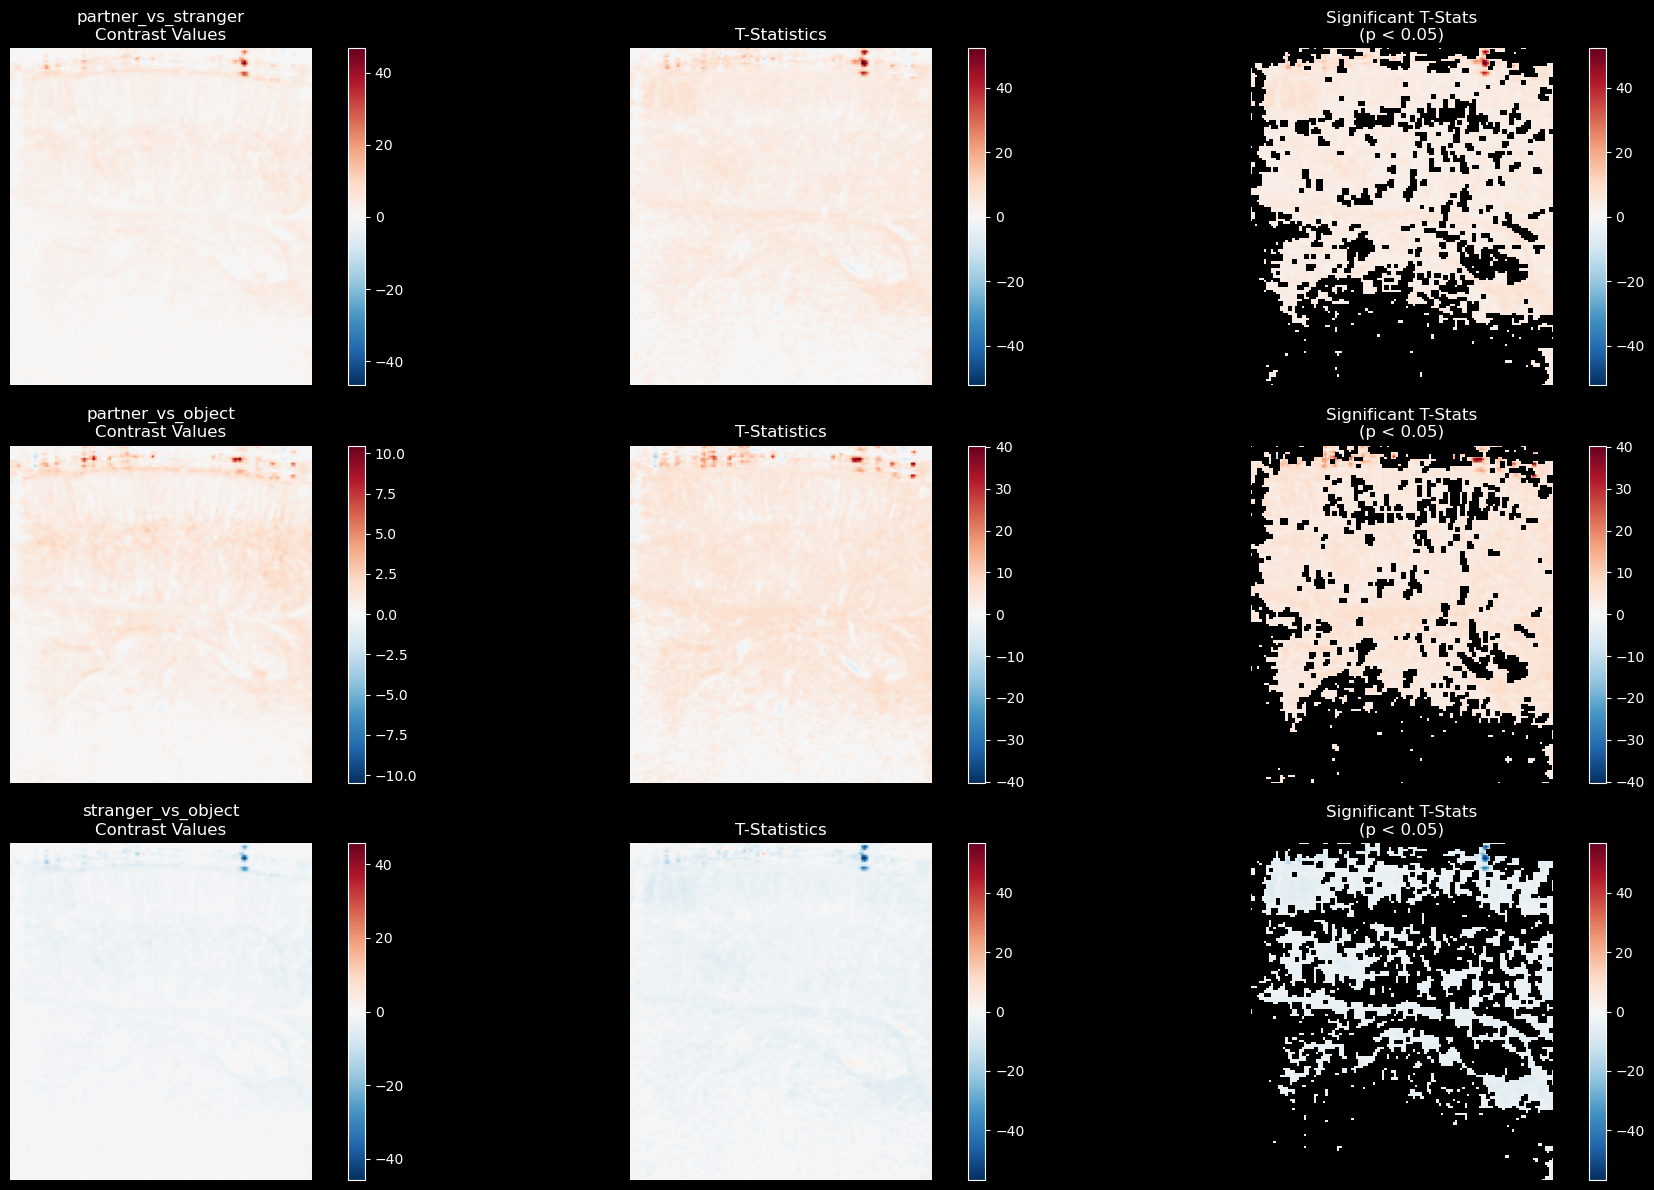

In [27]:
# Usage example:
# Plot the contrasts
fig_video = plot_multiple_contrasts(contrast_maps_video)
fig_video.show()


In [28]:
summarize_contrast_stats(contrast_maps_video)


Contrast: partner_vs_stranger
--------------------------------------------------
Contrast values range: [-5.823, 46.712]
T-statistics range: [-11.421, 52.221]
Number of significant voxels (p < 0.05): 12900
Number of significant voxels (p < 0.01): 10933
Number of significant voxels (p < 0.001): 8123

Contrast: partner_vs_object
--------------------------------------------------
Contrast values range: [-3.132, 10.469]
T-statistics range: [-13.372, 40.262]
Number of significant voxels (p < 0.05): 13123
Number of significant voxels (p < 0.01): 11448
Number of significant voxels (p < 0.001): 9111

Contrast: stranger_vs_object
--------------------------------------------------
Contrast values range: [-45.796, 7.766]
T-statistics range: [-56.659, 16.857]
Number of significant voxels (p < 0.05): 9285
Number of significant voxels (p < 0.01): 6113
Number of significant voxels (p < 0.001): 3119
